# KNN Classification

Ноутбук:

- Как работает классификация по ближайшим соседям
- Почему важно масштабирование признаков
- Влияние количества соседей
- Разница между весами
- Метрики качества: Accuracy, Precision, Recall, F1-score, ROC-AUC

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Данные

Сгенерируем датасет с двумя классами.

In [2]:
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=1.2, random_state=42)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y
df.head()

,feature_1,feature_2,target
0,1.631868,-1.153095,0
1,0.523473,-2.033522,0
2,1.177841,1.701977,1
3,2.186525,0.402109,0
4,1.556117,0.480041,1


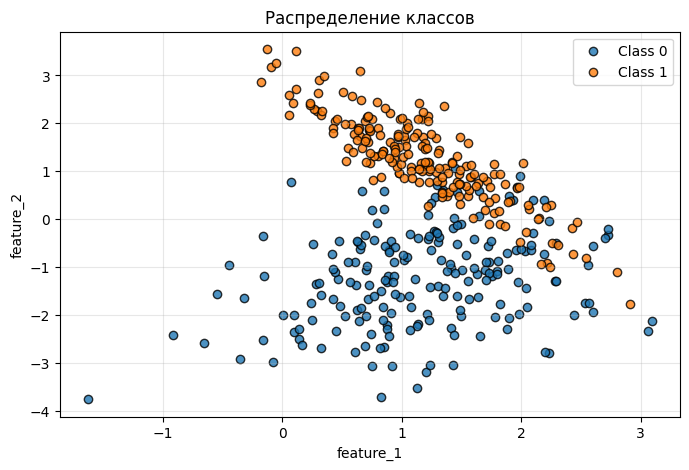

In [3]:
plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', label='Class 0', edgecolor='k', alpha=0.8)
plt.scatter(X[y==1, 0], X[y==1, 1], c='tab:orange', label='Class 1', edgecolor='k', alpha=0.8)
plt.xlabel('feature_1'); plt.ylabel('feature_2')
plt.title('Распределение классов')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 2. Как работает KNN

Алгоритм очень прост:
1. Берём новую точку.
2. Находим **k ближайших** к ней объектов из обучающей выборки.
3. Смотрим, какой класс встречается чаще среди соседей — он и будет ответом.

Никакого «обучения» в привычном смысле нет — модель просто запоминает данные.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print('Accuracy на тесте:', round(knn.score(X_test, y_test), 3))

Accuracy на тесте: 0.9


### Decision boundary

Визуализируем границу принятия решения: для каждой точки плоскости предскажем класс.

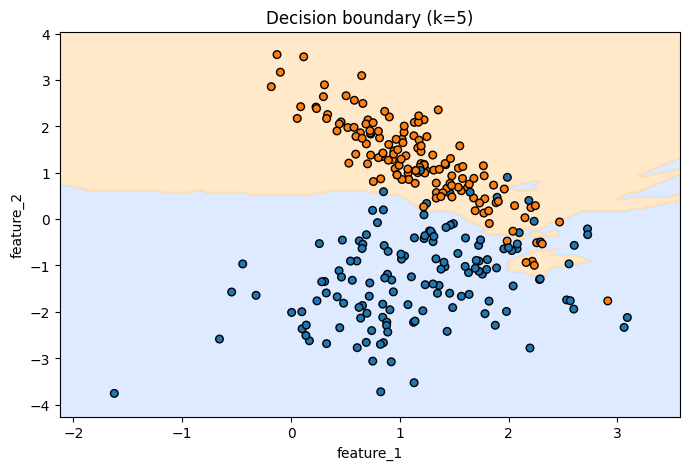

In [5]:
def plot_decision_boundary(model, X, y, title=''):
    h = 0.05
    x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg = ListedColormap(['#cfe2ff', '#ffe0b3'])
    cmap_pt = ListedColormap(['tab:blue', 'tab:orange'])
    plt.figure()
    plt.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pt, edgecolor='k', s=30)
    plt.xlabel('feature_1'); plt.ylabel('feature_2')
    plt.title(title); plt.show()

plot_decision_boundary(knn, X_train, y_train, 'Decision boundary (k=5)')

## 3. Почему важно масштабирование

KNN использует **расстояние** между точками. Если один признак измеряется в тысячах, а другой в десятых — он будет «перекрикивать» остальные.

Сделаем эксперимент: умножим один признак на 1000.

In [6]:
X_bad = X.copy()
X_bad[:, 0] *= 1000

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_bad, y, test_size=0.3, random_state=42, stratify=y)

# Без масштабирования
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(Xb_tr, yb_tr)
acc_raw = knn_raw.score(Xb_te, yb_te)

# С масштабированием
scaler = StandardScaler().fit(Xb_tr)
knn_sc = KNeighborsClassifier(n_neighbors=5).fit(scaler.transform(Xb_tr), yb_tr)
acc_sc = knn_sc.score(scaler.transform(Xb_te), yb_te)

print(f'Accuracy без масштабирования: {acc_raw:.3f}')
print(f'Accuracy с масштабированием:   {acc_sc:.3f}')

Accuracy без масштабирования: 0.558
Accuracy с масштабированием:   0.883


Видно, что без масштабирования качество заметно падает. **Вывод:** перед KNN почти всегда нужно применять методы масштабирования (`StandardScaler` или `MinMaxScaler`).

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

## 4. Влияние количества соседей

- Маленькое `k` → модель чувствительна к шуму, граница «рваная» (переобучение).
- Большое `k` → граница слишком гладкая, теряются детали (недообучение).

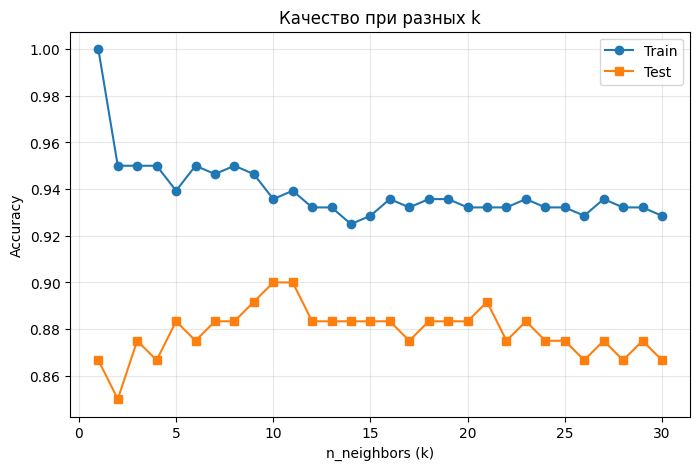

Лучшее k по тесту: 10


In [8]:
ks = range(1, 31)
train_acc, test_acc = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    train_acc.append(m.score(X_train_s, y_train))
    test_acc.append(m.score(X_test_s, y_test))

plt.figure()
plt.plot(ks, train_acc, 'o-', label='Train')
plt.plot(ks, test_acc,  's-', label='Test')
plt.xlabel('n_neighbors (k)'); plt.ylabel('Accuracy')
plt.title('Качество при разных k')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

best_k = ks[int(np.argmax(test_acc))]
print('Лучшее k по тесту:', best_k)

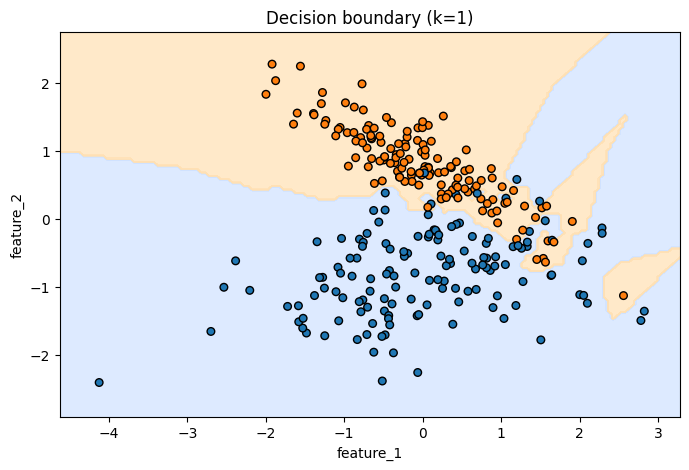

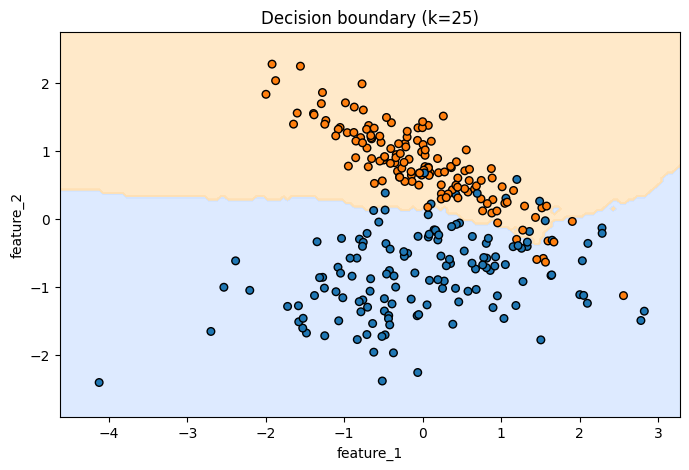

In [9]:
for k in [1, 25]:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    plot_decision_boundary(m, X_train_s, y_train, f'Decision boundary (k={k})')

## 5. Разница весов: `weights='uniform'` vs `weights='distance'`

- **uniform** — все k соседей голосуют одинаково.
- **distance** — ближайшие соседи имеют больший вес (вес = 1 / расстояние).

Второй вариант обычно даёт более «детальную» границу.

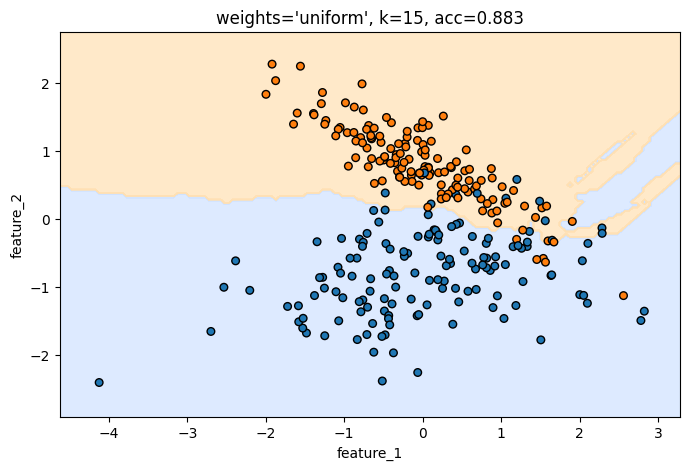

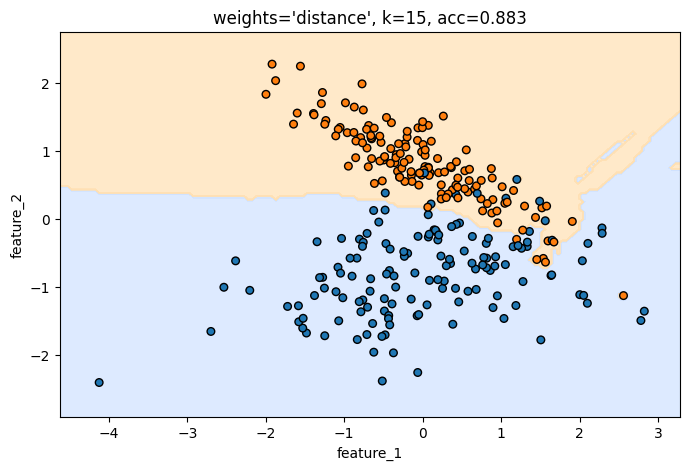

In [10]:
for w in ['uniform', 'distance']:
    m = KNeighborsClassifier(n_neighbors=15, weights=w).fit(X_train_s, y_train)
    acc = m.score(X_test_s, y_test)
    plot_decision_boundary(m, X_train_s, y_train, f"weights='{w}', k=15, acc={acc:.3f}")

## 6. Метрики качества

Возьмём финальную модель и посчитаем основные метрики.

In [11]:
model = KNeighborsClassifier(n_neighbors=best_k, weights='distance').fit(X_train_s, y_train)
y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_proba),
}
pd.Series(metrics).round(3)

,0
Accuracy,0.892
Precision,0.841
Recall,0.967
F1-score,0.899
ROC-AUC,0.951


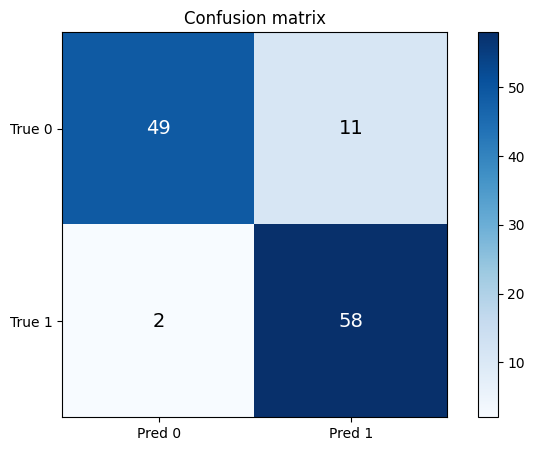

In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0', 'Pred 1']); ax.set_yticklabels(['True 0', 'True 1'])
ax.set_title('Confusion matrix')
plt.colorbar(im); plt.show()

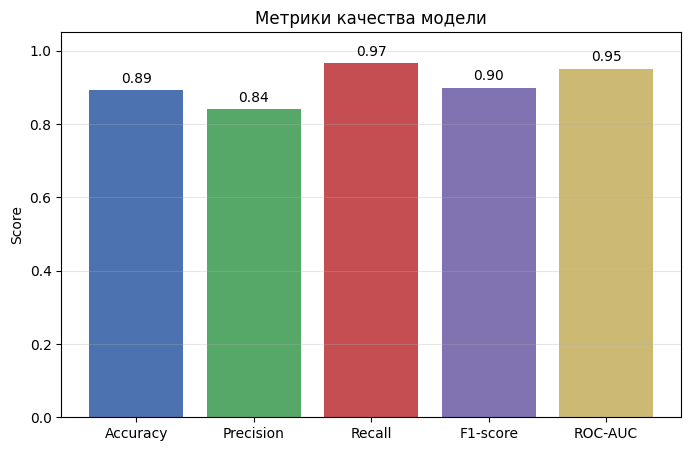

In [13]:
plt.figure()
bars = plt.bar(metrics.keys(), metrics.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'])
plt.ylim(0, 1.05)
plt.ylabel('Score'); plt.title('Метрики качества модели')
for b, v in zip(bars, metrics.values()):
    plt.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

#**Общий итог:**

- KNN классифицирует объект по большинству среди **k ближайших соседей**.
- Перед обучением **обязательно надо масштабировать признаки**.
- Параметр `n_neighbors` (количество соседей) контролирует баланс смещение/разброс — подбираем по тестовой выборке.
- `weights='distance'` часто даёт небольшой прирост качества за счёт учёта расстояний.
- Для оценки качества смотрим не только Accuracy, но и Precision / Recall / F1 / ROC-AUC.